# v3qc-v3 mixed-tier sweep vs hapFIRE — proper allele-aware comparison (SEEDMIX_S1 Chr1)

**Updated 2026-05-19.** v3qc-v3 = het-mask filter (replaces V4 record-drop) + pre-haploidized PG (works around bcftools merge mixed-ploidy bug). Uses cn_var_231_v3qc_v3 with called mask for AC/AN projection.

Comparing three k-mer-subset tiers on the same v3qc-v3 panel:
- **mixed-loose**:   ac_cactus ≥ 1  AND ac_pg ≥ 1
- **mixed-strict**:  ac_cactus ≥ 5  AND ac_pg ≥ 5
- **mixed-conserv**: ac_cactus ≥ 10 AND ac_pg ≥ 10


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from scipy.sparse import load_npz

ROOT = Path('/global/scratch/users/tbellg/kmate')
SCRATCH = ROOT / 'scratch'
HF_DIR = Path('/global/scratch/projects/fc_moilab/projects/grenenet-phase1/frequency/hapFIRE_frequencies/seed_mix')
CN_VAR_DIR = ROOT / 'data'

meta = np.load(CN_VAR_DIR / 'cn_var_231_v3qc_v3.meta.npz', allow_pickle=True)
rec_chrom = np.asarray(meta['chrom']).astype(str)
rec_pos   = np.asarray(meta['pos']).astype(np.int64)
rec_rlen  = np.asarray(meta['ref_len']).astype(np.int32)
rec_alen  = np.asarray(meta['alt_len']).astype(np.int32)
# Don't .astype(str) on ref/alt — some SV alleles are 100K+ bp so a fixed-width
# numpy string array would need 2.2 TB. Keep as object arrays.
rec_ref   = np.asarray(meta['ref'], dtype=object) if 'ref' in meta.files else None
rec_alt   = np.asarray(meta['alt'], dtype=object) if 'alt' in meta.files else None

print(f'meta keys: {meta.files}')
if rec_ref is not None:
    print(f'has REF/ALT base strings (new cn_var build): yes')
else:
    print(f'has REF/ALT base strings: NO — using position-only alignment')

chr1_snp_mask = (rec_chrom == 'Chr1') & (rec_rlen == 1) & (rec_alen == 1)
chr1_snp_idx = np.where(chr1_snp_mask)[0]
chr1_snp_pos = rec_pos[chr1_snp_idx]
print(f'Chr1 SNP records in cn_var_v3qc_v2: {len(chr1_snp_idx):,}')

cn_var = load_npz(CN_VAR_DIR / 'cn_var_231_v3qc_v3.cn_var.npz')
F = cn_var.shape[0]

called_path = CN_VAR_DIR / 'cn_var_231_v3qc_v3.cn_var_called.npz'
if called_path.exists():
    cn_var_called = load_npz(called_path)
    print(f'cn_var_called loaded: shape={cn_var_called.shape}, nnz={cn_var_called.nnz:,}')
else:
    cn_var_called = None
    print(f'WARNING: cn_var_called not found at {called_path} — fixed recipe unavailable')

meta keys: ['founders', 'chrom', 'pos', 'ref', 'alt', 'ref_len', 'alt_len']
has REF/ALT base strings (new cn_var build): yes
Chr1 SNP records in cn_var_v3qc_v2: 1,029,469


cn_var_called loaded: shape=(231, 6293085), nnz=1,364,381,666


In [2]:
# --- Build recipe truths ---
TRUTH_H = np.full(F, 1.0/F, dtype=np.float32)
cv_chr1 = cn_var[:, chr1_snp_idx].toarray().astype(np.float32)
recipe_legacy = TRUTH_H @ cv_chr1

if cn_var_called is not None:
    cvc_chr1 = cn_var_called[:, chr1_snp_idx].toarray().astype(np.float32)
    called_weight = TRUTH_H @ cvc_chr1
    safe = np.maximum(called_weight, 1e-12)
    recipe_fixed = (recipe_legacy / safe).astype(np.float32)
    # Diagnostic: how often does the fix differ from legacy?
    diff = recipe_fixed - recipe_legacy
    print(f'recipe_fixed - recipe_legacy: mean={diff.mean():+.4f}, max={diff.max():.4f}, min={diff.min():.4f}')
    print(f'records where |fix-legacy|>0.1: {(np.abs(diff)>0.1).sum():,} ({(np.abs(diff)>0.1).mean()*100:.2f}%)')
    print(f'  fix - legacy positive: {(diff>0.01).sum():,}, negative: {(diff<-0.01).sum():,}')
else:
    recipe_fixed = None

print(f'\nrecipe_legacy: min={recipe_legacy.min():.4f}, max={recipe_legacy.max():.4f}, mean={recipe_legacy.mean():.4f}')
if recipe_fixed is not None:
    print(f'recipe_fixed:  min={recipe_fixed.min():.4f}, max={recipe_fixed.max():.4f}, mean={recipe_fixed.mean():.4f}')

recipe_fixed - recipe_legacy: mean=+0.0075, max=0.8788, min=0.0000
records where |fix-legacy|>0.1: 11,886 (1.15%)
  fix - legacy positive: 145,107, negative: 0

recipe_legacy: min=0.0043, max=1.0000, mean=0.1029
recipe_fixed:  min=0.0043, max=1.0000, mean=0.1104


In [3]:
# --- Load each retest config: prefer FIXED rerun if present, fall back to old rerun ---
CONFIGS = {
    'v3qc_v3 mixed-loose (>=1+1)':    ['v3qc_v3_mixedloose_chr1'],
    'v3qc_v3 mixed-strict (>=5+5)':   ['v3qc_v3_mixedstrict_chr1'],
    'v3qc_v3 mixed-conserv (>=10+10)':['v3qc_v3_mixedconserv_chr1'],
}

def load_cem_chr1_snp_af(tsv_path):
    df = pd.read_csv(tsv_path, sep='\t')
    return df['alt_freq'].to_numpy()[chr1_snp_idx]

cem_af = {}
config_source = {}
for name, candidates in CONFIGS.items():
    found = None
    for c in candidates:
        p = SCRATCH / c / 'SEEDMIX_S1.tsv'
        if p.exists():
            found = p
            break
    if found is None:
        print(f'  ✗ MISSING: {name}')
        continue
    cem_af[name] = load_cem_chr1_snp_af(found)
    config_source[name] = found.parent.name
    tag = 'FIXED' if ('FIXED' in found.parent.name or 'NEW' in found.parent.name) else 'legacy'
    print(f'  ✓ {name} ({tag}): n={len(cem_af[name]):,}')

# --- hapFIRE: xwu's per-SNP AF for SEEDMIX_S1, aligned to our positions ---
hf_raw = pd.read_csv(HF_DIR / 's1_snp_frequency.txt', sep='\t',
                     header=None, names=['chrom','pos','af'])
hf_raw = hf_raw[hf_raw['chrom'].astype(str) == '1']
hf_d = dict(zip(hf_raw['pos'].astype(np.int64), hf_raw['af'].astype(np.float32)))
hf_af = np.array([hf_d.get(p, np.nan) for p in chr1_snp_pos], dtype=np.float32)
print(f'\nhapFIRE aligned: n_finite={np.isfinite(hf_af).sum():,} / {len(hf_af):,}')

# --- Optional: mask out multi-allelic positions for cleaner hapFIRE join ---
# At a multi-allelic position, we have N decomposed biallelic SNP records but
# hapFIRE reports ONE AF per position; the N-1 minor-ALT records would alias
# to the major-ALT's hapFIRE AF and appear as false off-diagonal scatter.
from collections import Counter
pos_counts = Counter(chr1_snp_pos.tolist())
single_alt_mask = np.array([pos_counts[p] == 1 for p in chr1_snp_pos])
print(f'Single-ALT positions (clean for hapFIRE join): {single_alt_mask.sum():,} / {len(chr1_snp_pos):,}')

  ✓ v3qc_v3 mixed-loose (>=1+1) (legacy): n=1,029,469


  ✓ v3qc_v3 mixed-strict (>=5+5) (legacy): n=1,029,469


  ✓ v3qc_v3 mixed-conserv (>=10+10) (legacy): n=1,029,469



hapFIRE aligned: n_finite=520,936 / 1,029,469


Single-ALT positions (clean for hapFIRE join): 977,483 / 1,029,469


In [4]:
def metrics(x, y, mask=None):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if mask is not None:
        finite = finite & mask
    if finite.sum() < 5:
        return None
    xv = x[finite]; yv = y[finite]
    return dict(
        n=int(finite.sum()),
        r2=float(np.corrcoef(xv, yv)[0,1]**2),
        mae=float(np.mean(np.abs(yv - xv))),
        rmse=float(np.sqrt(np.mean((yv - xv)**2))),
        slope=float(np.polyfit(xv, yv, 1)[0]),
        signed=float(np.mean(yv - xv)),
        out=float(np.mean(np.abs(yv - xv) > 0.1)),
    )

def hexbin(ax, x, y, xlabel, ylabel, title, mask=None):
    finite = np.isfinite(x) & np.isfinite(y) & (x >= 0) & (x <= 1) & (y >= 0) & (y <= 1)
    if mask is not None:
        finite = finite & mask
    if finite.sum() < 5:
        ax.text(0.5, 0.5, 'no overlap', ha='center', va='center')
        return
    hb = ax.hexbin(x[finite], y[finite], gridsize=80, cmap='viridis',
                   norm=LogNorm(), mincnt=1)
    ax.plot([0,1],[0,1],'r--', lw=0.7, alpha=0.7)
    ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
    ax.set_xlabel(xlabel); ax.set_ylabel(ylabel)
    m = metrics(x, y, mask)
    ax.set_title(
        f'{title}\nR²={m["r2"]:.4f}  MAE={m["mae"]:.4f}  RMSE={m["rmse"]:.4f}\n'
        f'slope={m["slope"]:+.3f}  signed={m["signed"]:+.4f}  out={100*m["out"]:.2f}%',
        fontsize=9)
    plt.colorbar(hb, ax=ax, label='log10(count)', fraction=0.046, pad=0.04)

## Diagnostic: legacy recipe vs fixed recipe vs hapFIRE

Confirms the cn_var fix. If everything's correct, fixed-recipe should match hapFIRE very closely (MAE ~0.02, R²~0.95), while legacy-recipe shows the structural slope=1.09 deviation.

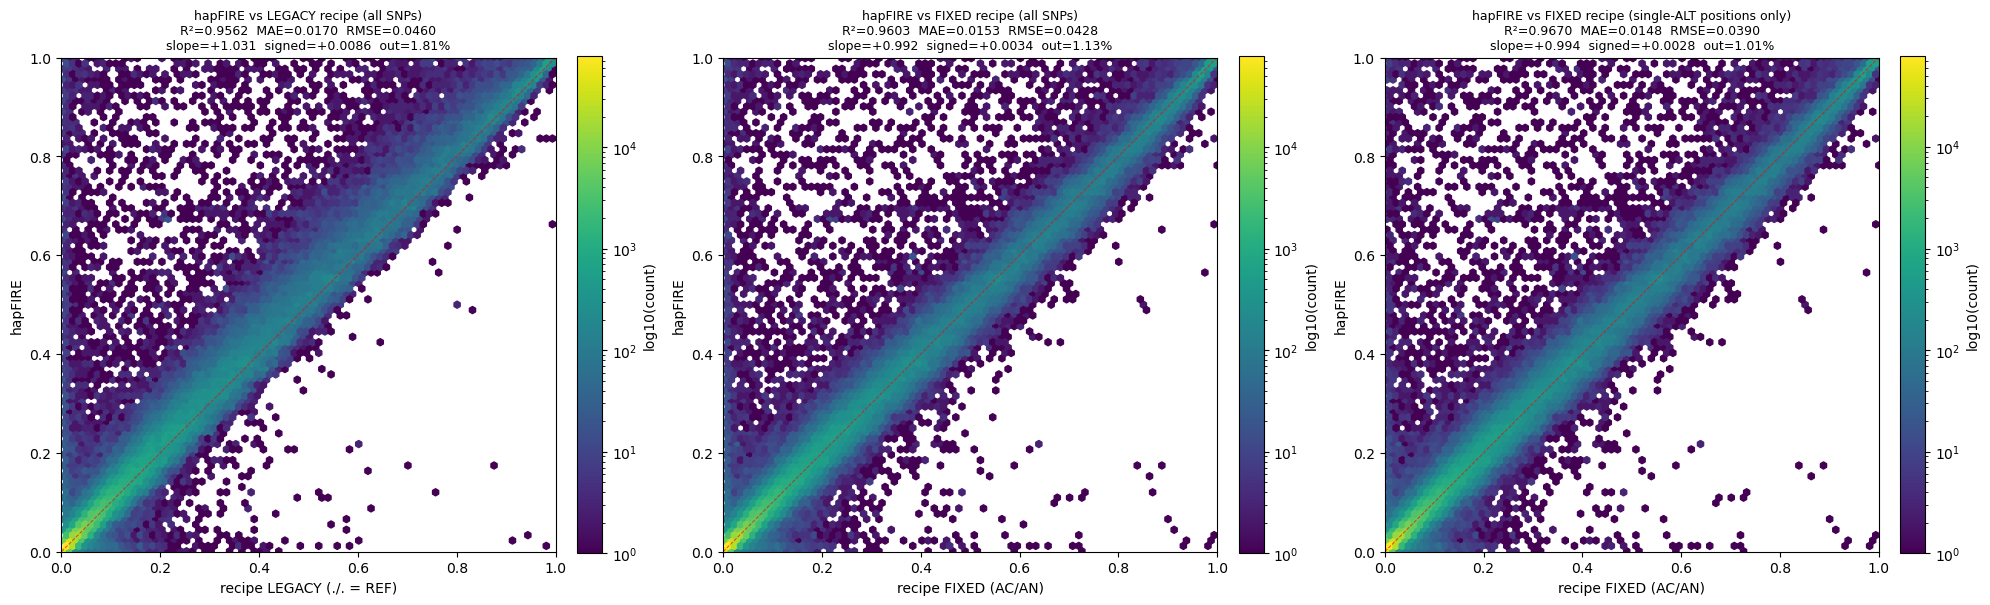

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6.5))
hexbin(axes[0], recipe_legacy, hf_af, 'recipe LEGACY (./. = REF)', 'hapFIRE',
       'hapFIRE vs LEGACY recipe (all SNPs)')
if recipe_fixed is not None:
    hexbin(axes[1], recipe_fixed, hf_af, 'recipe FIXED (AC/AN)', 'hapFIRE',
           'hapFIRE vs FIXED recipe (all SNPs)')
    hexbin(axes[2], recipe_fixed, hf_af, 'recipe FIXED (AC/AN)', 'hapFIRE',
           'hapFIRE vs FIXED recipe (single-ALT positions only)',
           mask=single_alt_mask)
else:
    axes[1].text(0.5, 0.5, 'cn_var_called not yet built', ha='center', va='center')
    axes[2].axis('off')
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_v3qc_v3_recipe_fix.png', dpi=130, bbox_inches='tight')
plt.show()

## Per-config scatter grid (vs FIXED recipe + vs hapFIRE)

Row 0 is hapFIRE itself for reference. Subsequent rows are each cactus_em config.

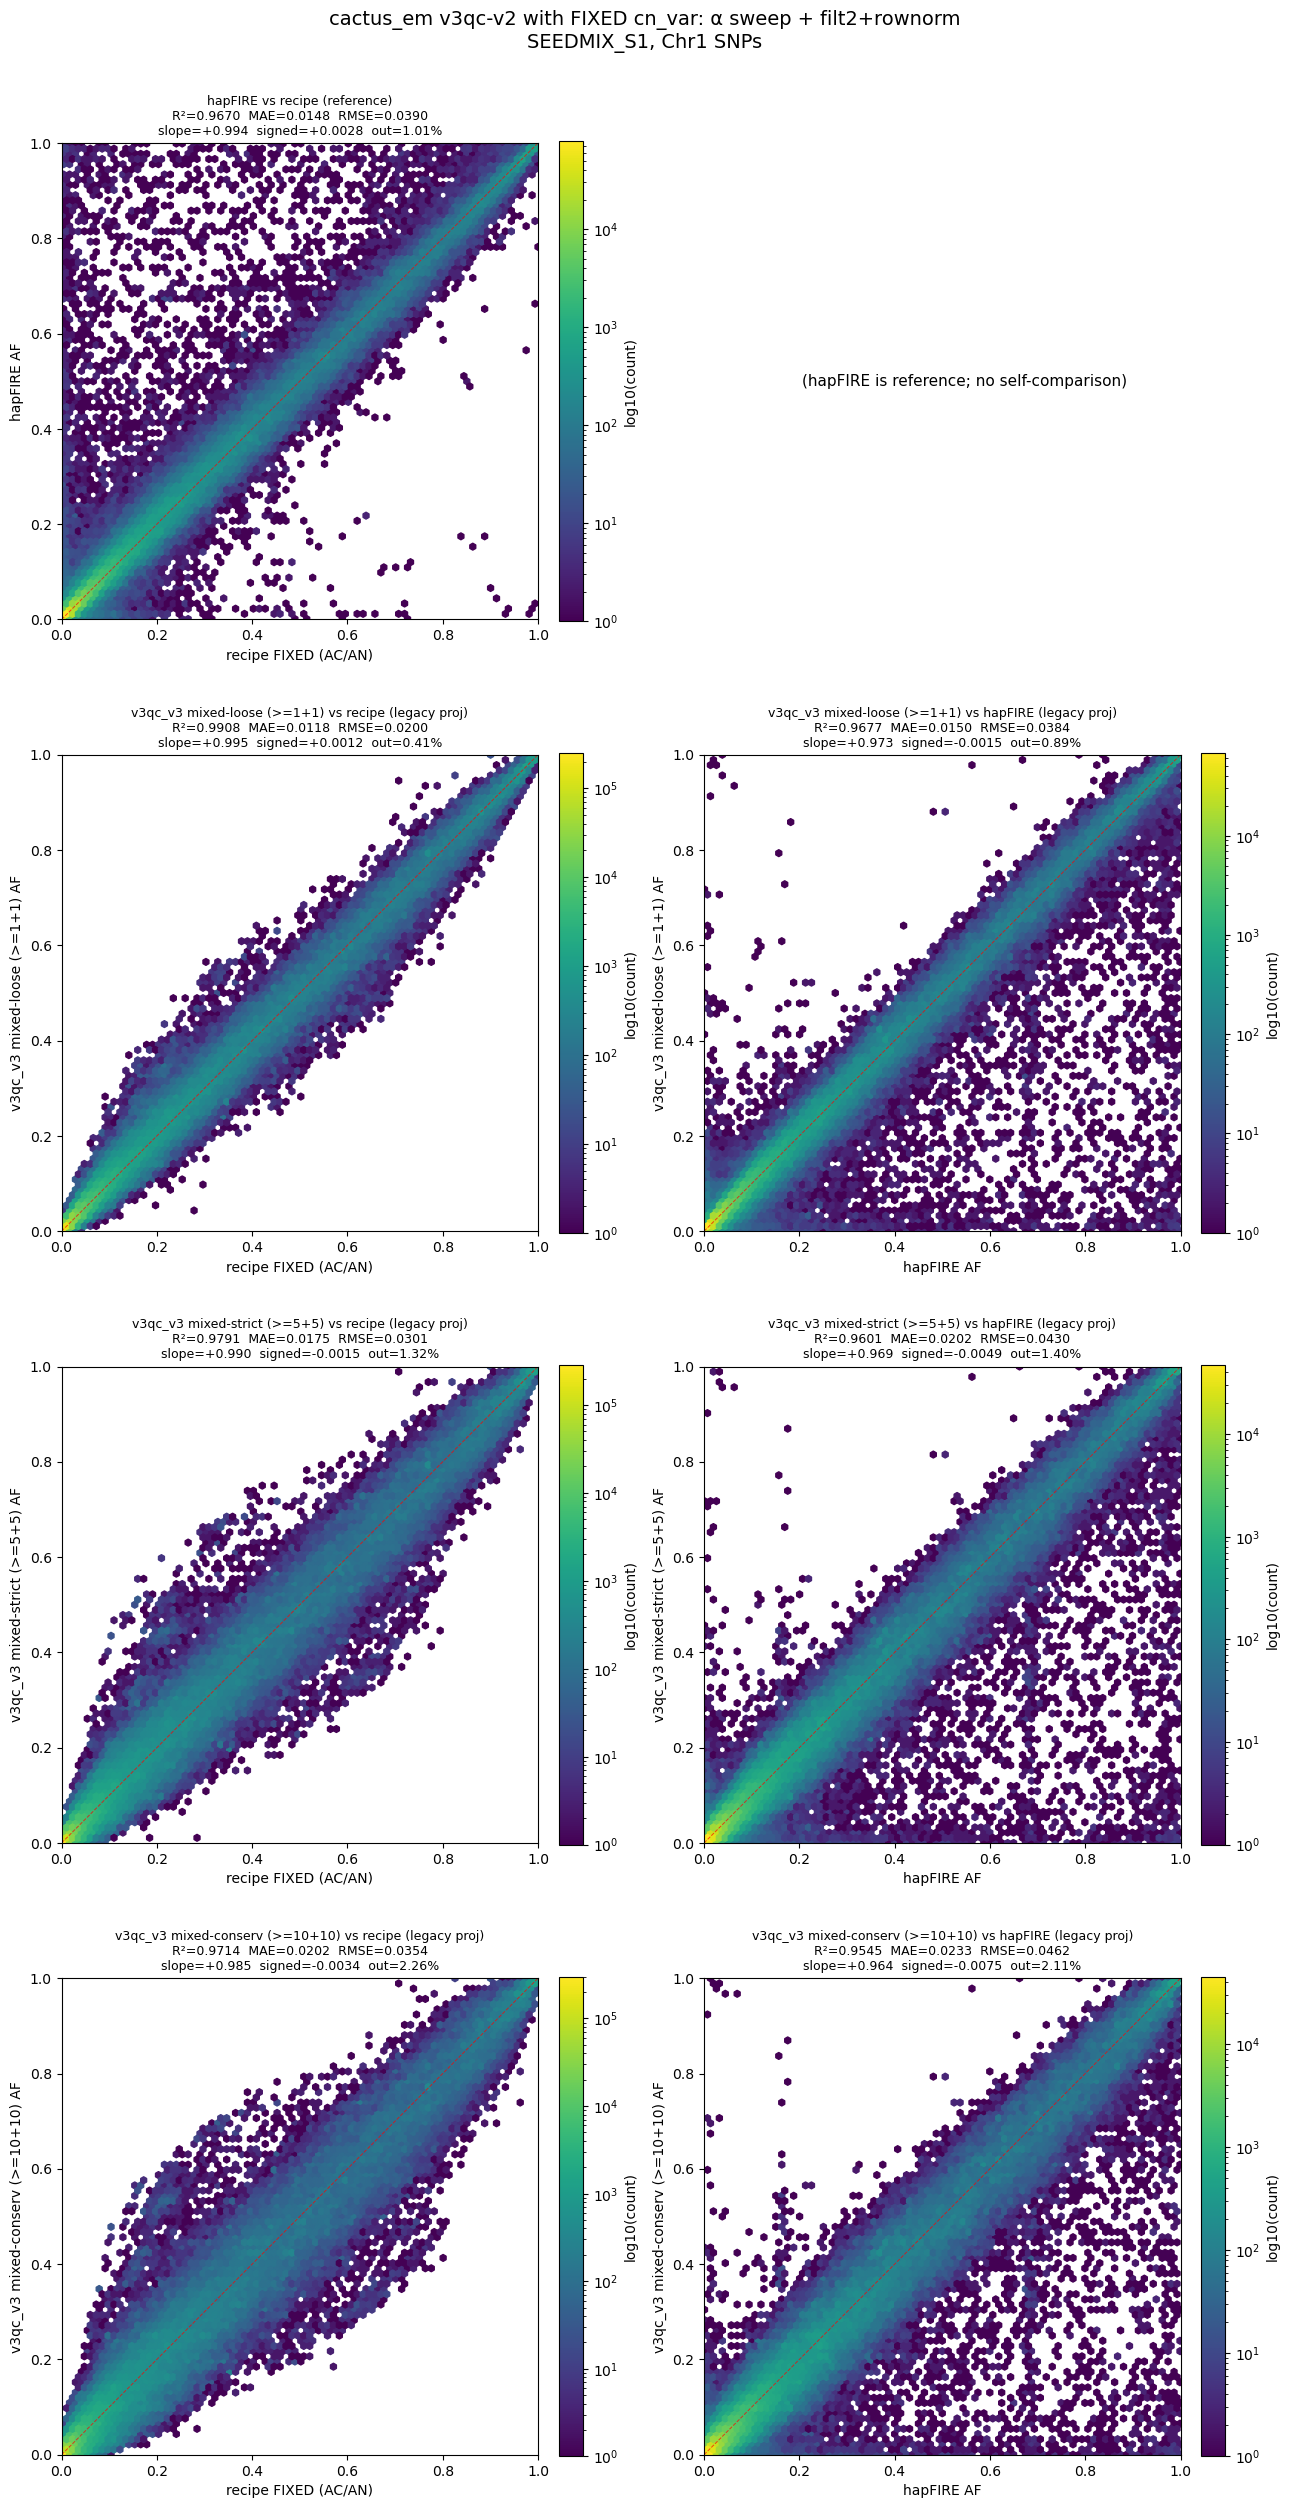

In [6]:
ref_truth = recipe_fixed if recipe_fixed is not None else recipe_legacy
ref_label = 'recipe FIXED (AC/AN)' if recipe_fixed is not None else 'recipe LEGACY'

method_names = list(cem_af.keys())
n_rows = 1 + len(method_names)
fig, axes = plt.subplots(n_rows, 2, figsize=(13, 6.3 * n_rows))
if n_rows == 1:
    axes = np.atleast_2d(axes)

hexbin(axes[0, 0], ref_truth, hf_af, ref_label, 'hapFIRE AF',
       'hapFIRE vs recipe (reference)', mask=single_alt_mask)
axes[0, 1].axis('off')
axes[0, 1].text(0.5, 0.5, '(hapFIRE is reference; no self-comparison)',
                ha='center', va='center', fontsize=11, transform=axes[0, 1].transAxes)

for i, name in enumerate(method_names, start=1):
    cem = cem_af[name]
    src_tag = 'FIXED proj' if ('FIXED' in config_source.get(name, '') or 'NEW' in config_source.get(name, '')) else 'legacy proj'
    hexbin(axes[i, 0], ref_truth, cem, ref_label, f'{name} AF',
           f'{name} vs recipe ({src_tag})')
    hexbin(axes[i, 1], hf_af,    cem, 'hapFIRE AF',                f'{name} AF',
           f'{name} vs hapFIRE ({src_tag})', mask=single_alt_mask)

fig.suptitle('cactus_em v3qc-v2 with FIXED cn_var: α sweep + filt2+rownorm\n'
             'SEEDMIX_S1, Chr1 SNPs', y=0.999, fontsize=14)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_v3qc_v3_mixedloose.png', dpi=130, bbox_inches='tight')
plt.show()

## Summary table + Pareto

In [7]:
rows = []
m = metrics(ref_truth, hf_af, single_alt_mask)
if m is not None:
    rows.append({'method': 'hapFIRE', 'reference': ref_label, **{k:m[k] for k in ['n','r2','mae','rmse','slope','signed','out']}})
for name in method_names:
    cem = cem_af[name]
    for ref_name, ref_v, mk in [(ref_label, ref_truth, None), ('hapFIRE', hf_af, single_alt_mask)]:
        m = metrics(ref_v, cem, mk)
        if m is not None:
            rows.append({'method': name, 'reference': ref_name, **{k:m[k] for k in ['n','r2','mae','rmse','slope','signed','out']}})
tbl = pd.DataFrame(rows)
for col in ['r2','mae','rmse','slope','signed']:
    tbl[col] = tbl[col].map(lambda x: f'{x:.4f}')
tbl['out'] = tbl['out'].map(lambda x: f'{100*x:.2f}%')
print(tbl.to_string(index=False))

                         method            reference       n     r2    mae   rmse  slope  signed   out
                        hapFIRE recipe FIXED (AC/AN)  517217 0.9670 0.0148 0.0390 0.9936  0.0028 1.01%
    v3qc_v3 mixed-loose (>=1+1) recipe FIXED (AC/AN) 1029469 0.9908 0.0118 0.0200 0.9954  0.0012 0.41%
    v3qc_v3 mixed-loose (>=1+1)              hapFIRE  517217 0.9677 0.0150 0.0384 0.9731 -0.0015 0.89%
   v3qc_v3 mixed-strict (>=5+5) recipe FIXED (AC/AN) 1029469 0.9791 0.0175 0.0301 0.9899 -0.0015 1.32%
   v3qc_v3 mixed-strict (>=5+5)              hapFIRE  517217 0.9601 0.0202 0.0430 0.9687 -0.0049 1.40%
v3qc_v3 mixed-conserv (>=10+10) recipe FIXED (AC/AN) 1029469 0.9714 0.0202 0.0354 0.9853 -0.0034 2.26%
v3qc_v3 mixed-conserv (>=10+10)              hapFIRE  517217 0.9545 0.0233 0.0462 0.9636 -0.0075 2.11%


                         config  h_bias  mae_vs_recipe_FIXED  mae_vs_hapFIRE
    v3qc_v3 mixed-loose (>=1+1)  2.2902               0.0118          0.0150
   v3qc_v3 mixed-strict (>=5+5)  2.7214               0.0175          0.0202
v3qc_v3 mixed-conserv (>=10+10)  2.5671               0.0202          0.0233


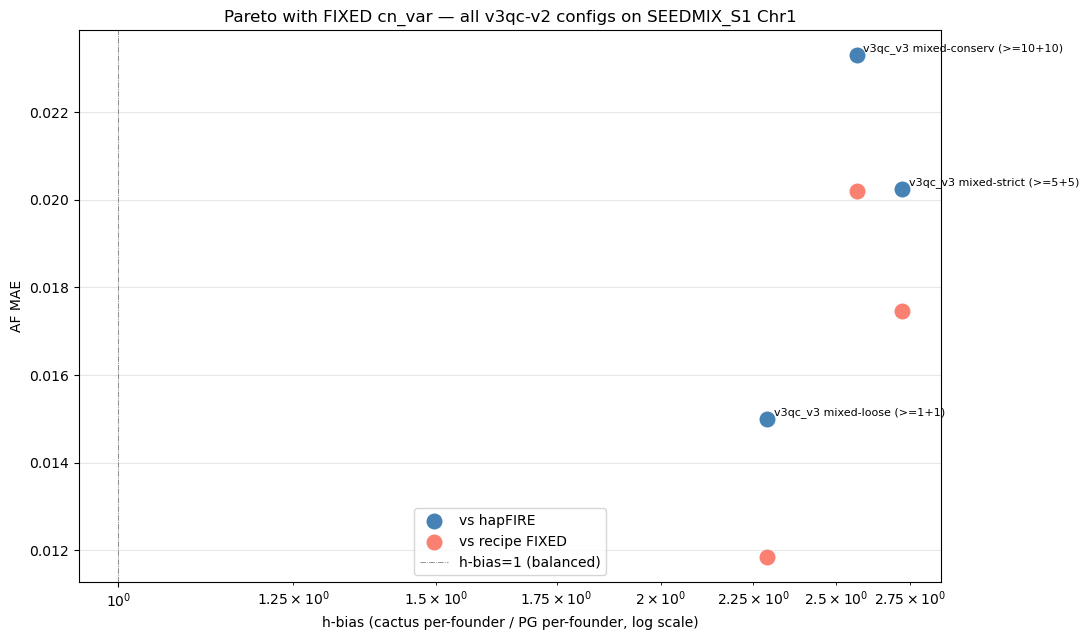

In [8]:
import json
with open(ROOT / 'data/founder_split_cactus_pg.json') as f:
    split = json.load(f)
cactus_set = set(map(str, split['cactus']))
pg_set = set(map(str, split['PG']))

def h_bias_from_npz(npz_path):
    d = np.load(npz_path, allow_pickle=True)
    founders = list(d['founders'])
    h = d['Chr1']
    is_c = np.array([f in cactus_set for f in founders])
    is_p = np.array([f in pg_set for f in founders])
    pf_c = h[is_c].sum() / is_c.sum()
    pf_p = h[is_p].sum() / is_p.sum()
    return pf_c / pf_p if pf_p > 0 else np.nan

summary = []
for name in method_names:
    cand = config_source.get(name)
    if cand is None:
        continue
    npz = SCRATCH / cand / 'SEEDMIX_S1.h_per_chrom.npz'
    if not npz.exists():
        continue
    bias = h_bias_from_npz(npz)
    cem = cem_af[name]
    m_rec = metrics(ref_truth, cem)
    m_hf  = metrics(hf_af, cem, single_alt_mask)
    summary.append({
        'config': name, 'h_bias': bias,
        'mae_vs_recipe_FIXED': m_rec['mae'] if m_rec else np.nan,
        'mae_vs_hapFIRE':       m_hf['mae'] if m_hf else np.nan,
    })
summary_df = pd.DataFrame(summary)
print(summary_df.to_string(index=False, float_format='%.4f'))

fig, ax = plt.subplots(figsize=(11, 6.5))
ax.scatter(summary_df['h_bias'], summary_df['mae_vs_hapFIRE'], s=110, c='steelblue', label='vs hapFIRE')
ax.scatter(summary_df['h_bias'], summary_df['mae_vs_recipe_FIXED'], s=110, c='salmon', label='vs recipe FIXED')
for _, r in summary_df.iterrows():
    ax.annotate(r['config'], (r['h_bias'], r['mae_vs_hapFIRE']),
                fontsize=8, xytext=(5, 3), textcoords='offset points')
ax.axvline(1.0, c='gray', ls='-.', lw=0.6, label='h-bias=1 (balanced)')
ax.set_xscale('log')
ax.set_xlabel('h-bias (cactus per-founder / PG per-founder, log scale)')
ax.set_ylabel('AF MAE')
ax.set_title('Pareto with FIXED cn_var — all v3qc-v2 configs on SEEDMIX_S1 Chr1')
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_v3qc_v3_pareto.png', dpi=130, bbox_inches='tight')
plt.show()

## Outlier diagnostic — same scatter colored by (1) genomic region, (2) F_MISSING

Reveal where the off-diagonal scatter cloud actually lives.

- **Region color**: Chr1 split into arm-p (1–14Mb), centromere (~14–17Mb), arm-q (17–30.5Mb)
- **F_MISSING color**: continuous, red = high missingness in v3qc_v3 cn_var at that record

n records plotted (single-ALT, in-range): 517,217


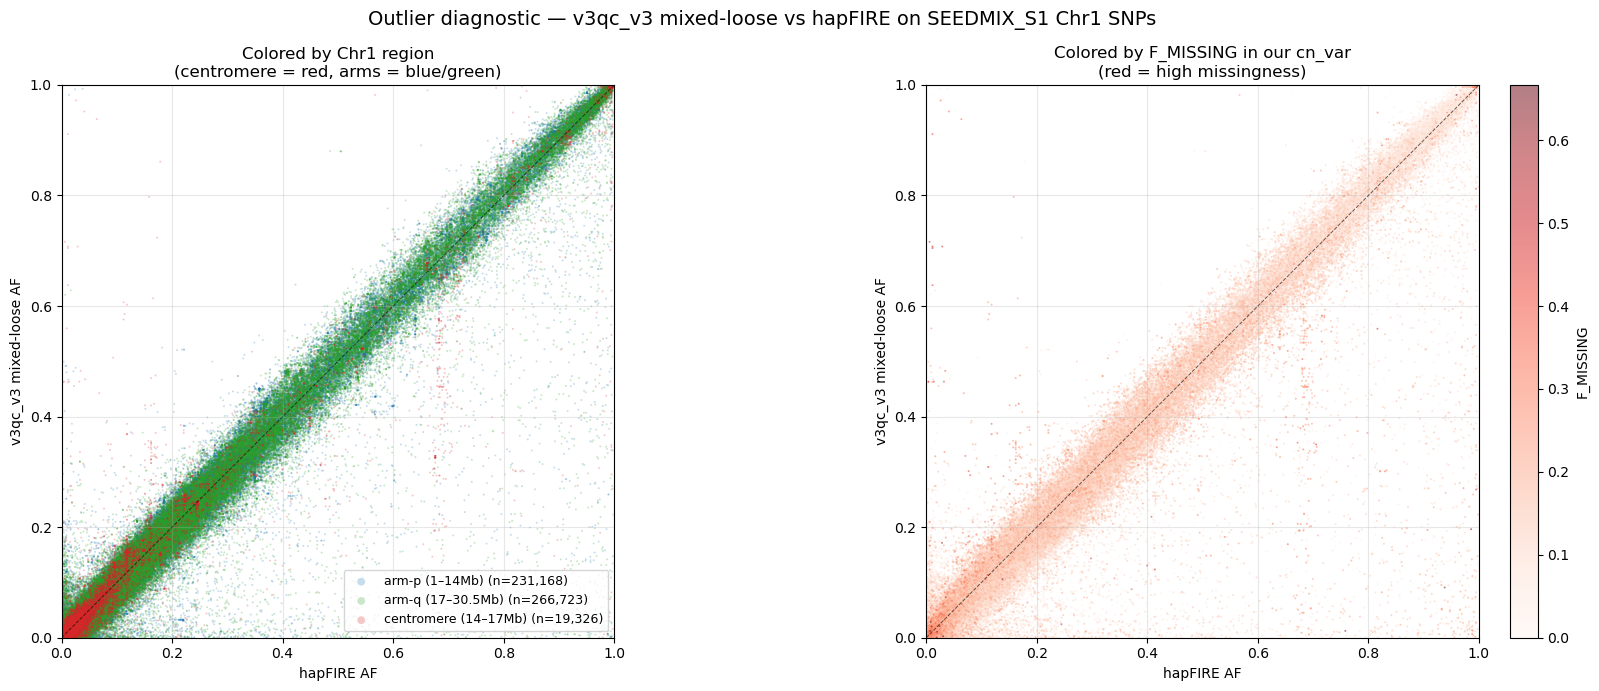


=== Outlier rate (|diff|>0.1) by region ===
  arm-p (1–14Mb): n=231,168, outliers=1,851 (0.80%)
  centromere (14–17Mb): n=19,326, outliers=590 (3.05%)
  arm-q (17–30.5Mb): n=266,723, outliers=2,156 (0.81%)

=== Outlier rate by F_MISSING bin ===
  F∈[0,0.01): n=312,325  outliers=  284  ( 0.09%)
  F∈[0.01,0.05): n=130,541  outliers=1,019  ( 0.78%)
  F∈[0.05,0.1): n= 48,286  outliers=1,256  ( 2.60%)
  F∈[0.1,0.2): n= 24,210  outliers=1,560  ( 6.44%)
  F∈[0.2,0.5): n=  1,834  outliers=  467  (25.46%)
  F∈[0.5,1.01): n=     21  outliers=   11  (52.38%)


In [9]:
# Build aligned arrays for the v3qc_v3 mixed-loose vs hapFIRE scatter,
# enriched with genomic region and F_MISSING per record.
cem_v3 = cem_af['v3qc_v3 mixed-loose (>=1+1)']
finite = np.isfinite(cem_v3) & np.isfinite(hf_af) & (cem_v3>=0) & (cem_v3<=1) & (hf_af>=0) & (hf_af<=1) & single_alt_mask
n_finite = int(finite.sum())
print(f'n records plotted (single-ALT, in-range): {n_finite:,}')

# Per-record carriers + called → F_MISSING
carriers_chr1 = cv_chr1.sum(axis=0)
called_chr1   = cvc_chr1.sum(axis=0)
fmiss_chr1    = 1 - called_chr1 / F

# Region label per record (Chr1 only; centromere ~14–17 Mb per BACKGROUND.md)
mb_chr1 = chr1_snp_pos / 1e6
region_labels = np.where(mb_chr1 < 14, 'arm-p (1–14Mb)',
                  np.where(mb_chr1 <= 17, 'centromere (14–17Mb)', 'arm-q (17–30.5Mb)'))

x_hf  = hf_af[finite]
y_cem = cem_v3[finite]
fm    = fmiss_chr1[finite]
reg   = region_labels[finite]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# --- Left: colored by region ---
ax = axes[0]
region_colors = {
    'arm-p (1–14Mb)':         '#1f77b4',
    'centromere (14–17Mb)':   '#d62728',
    'arm-q (17–30.5Mb)':      '#2ca02c',
}
# Plot arms first (background), centromere on top (foreground)
for label in ['arm-p (1–14Mb)', 'arm-q (17–30.5Mb)', 'centromere (14–17Mb)']:
    sel = reg == label
    ax.scatter(x_hf[sel], y_cem[sel], c=region_colors[label], s=2, alpha=0.25,
               edgecolor='none', label=f'{label} (n={sel.sum():,})')
ax.plot([0,1],[0,1],'k--', lw=0.7, alpha=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('v3qc_v3 mixed-loose AF')
ax.set_title('Colored by Chr1 region\n(centromere = red, arms = blue/green)')
ax.legend(loc='lower right', fontsize=9, markerscale=4)
ax.grid(alpha=0.3)

# --- Right: colored by F_MISSING continuous (red = high missingness) ---
ax = axes[1]
order = np.argsort(fm)  # plot high-F last so red dots are on top
sc = ax.scatter(x_hf[order], y_cem[order], c=fm[order], cmap='Reds', s=2, alpha=0.5,
                edgecolor='none', vmin=0, vmax=fm.max())
ax.plot([0,1],[0,1],'k--', lw=0.7, alpha=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('hapFIRE AF'); ax.set_ylabel('v3qc_v3 mixed-loose AF')
ax.set_title('Colored by F_MISSING in our cn_var\n(red = high missingness)')
plt.colorbar(sc, ax=ax, label='F_MISSING', fraction=0.046, pad=0.04)
ax.grid(alpha=0.3)

plt.suptitle('Outlier diagnostic — v3qc_v3 mixed-loose vs hapFIRE on SEEDMIX_S1 Chr1 SNPs',
             fontsize=14)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_v3qc_v3_outlier_colormap.png', dpi=140, bbox_inches='tight')
plt.show()

# Side-numerical breakdown
print('\n=== Outlier rate (|diff|>0.1) by region ===')
diff = y_cem - x_hf
for label in ['arm-p (1–14Mb)', 'centromere (14–17Mb)', 'arm-q (17–30.5Mb)']:
    sel = reg == label
    n = sel.sum(); n_out = (np.abs(diff[sel])>0.1).sum()
    print(f'  {label}: n={n:,}, outliers={n_out:,} ({n_out/n*100:.2f}%)')

print('\n=== Outlier rate by F_MISSING bin ===')
for lo, hi in [(0, 0.01), (0.01, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.5), (0.5, 1.01)]:
    sel = (fm >= lo) & (fm < hi)
    n = sel.sum(); n_out = (np.abs(diff[sel])>0.1).sum() if n else 0
    pct = n_out/n*100 if n else 0
    print(f'  F∈[{lo},{hi}): n={n:>7,}  outliers={n_out:>5,}  ({pct:5.2f}%)')

## Outlier diagnostic — cem vs recipe FIXED, colored by F_MISSING

Same conventions as the cem-vs-hapFIRE diagnostic, but now the reference is the FIXED recipe (AC/AN projection). Mixed-loose vs recipe has R²=0.991 / MAE=0.012 — does the residual scatter correlate with F_MISSING?

n records plotted (vs FIXED recipe): 1,029,469


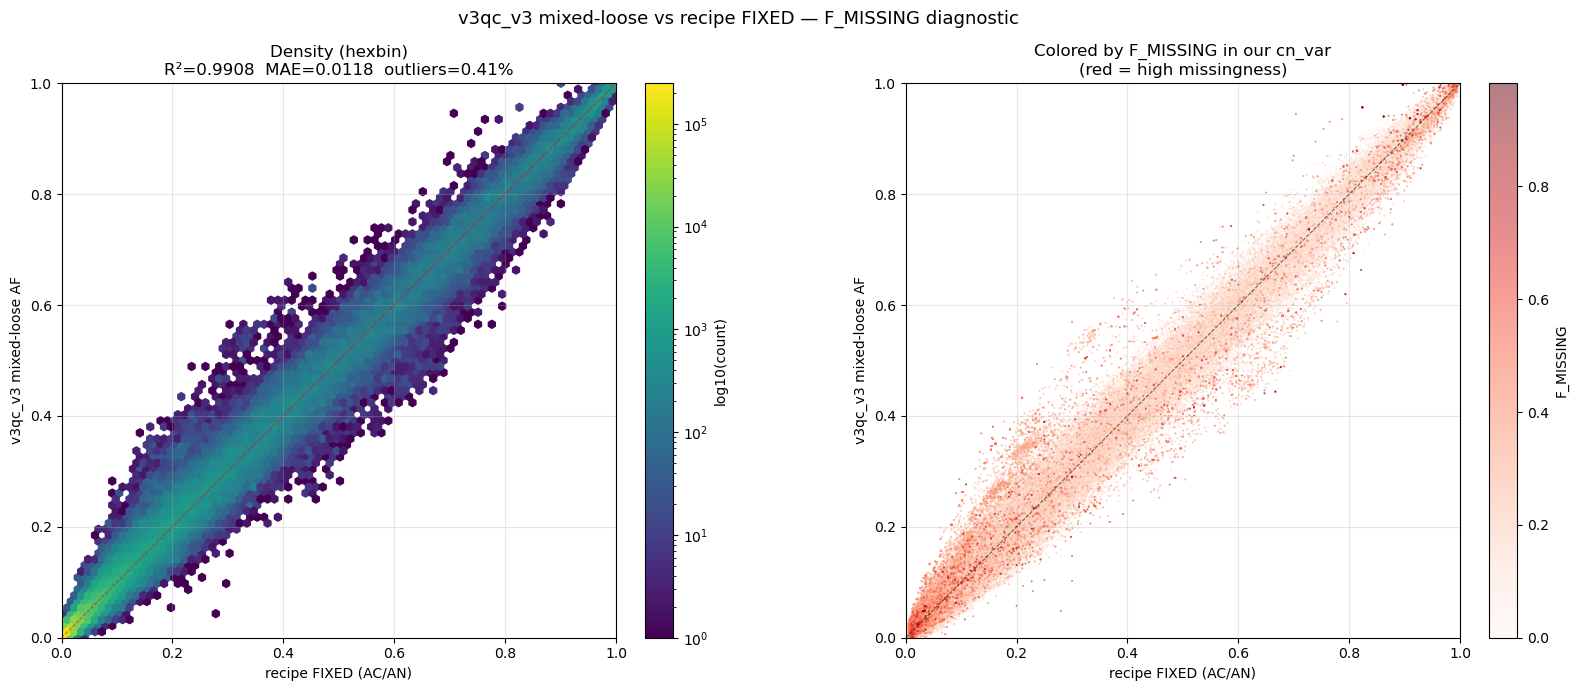


=== cem vs recipe FIXED: outlier rate by F_MISSING bin ===
  F∈[0,0.01): n=600,827  MAE=0.00730  outliers=  124 ( 0.02%)
  F∈[0.01,0.05): n=219,715  MAE=0.01558  outliers=  289 ( 0.13%)
  F∈[0.05,0.1): n=105,085  MAE=0.01868  outliers=  333 ( 0.32%)
  F∈[0.1,0.2): n= 70,203  MAE=0.01907  outliers=  364 ( 0.52%)
  F∈[0.2,0.5): n= 31,678  MAE=0.03117  outliers=2,759 ( 8.71%)
  F∈[0.5,1.01): n=  1,961  MAE=0.04977  outliers=  336 (17.13%)


In [10]:
# v3qc_v3 mixed-loose AF vs FIXED recipe, colored by F_MISSING.
# Use ALL records (not just single-ALT) since recipe truth doesn't have the
# hapFIRE multi-allelic-aliasing issue — recipe is per-record by construction.
cem_v3 = cem_af['v3qc_v3 mixed-loose (>=1+1)']
finite_r = np.isfinite(cem_v3) & np.isfinite(ref_truth) & (cem_v3>=0) & (cem_v3<=1) & (ref_truth>=0) & (ref_truth<=1)
print(f'n records plotted (vs FIXED recipe): {finite_r.sum():,}')

x_rec = ref_truth[finite_r]
y_cem = cem_v3[finite_r]
fm    = fmiss_chr1[finite_r]

fig, axes = plt.subplots(1, 2, figsize=(17, 7))

# --- Left: hexbin density (reference, no coloring) ---
ax = axes[0]
hb = ax.hexbin(x_rec, y_cem, gridsize=80, cmap='viridis', norm=LogNorm(), mincnt=1)
ax.plot([0,1],[0,1],'r--', lw=0.7, alpha=0.7)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('recipe FIXED (AC/AN)'); ax.set_ylabel('v3qc_v3 mixed-loose AF')
diff = y_cem - x_rec
mae = np.abs(diff).mean(); r2 = np.corrcoef(x_rec, y_cem)[0,1]**2
ax.set_title(f'Density (hexbin)\nR²={r2:.4f}  MAE={mae:.4f}  outliers={(np.abs(diff)>0.1).mean()*100:.2f}%')
plt.colorbar(hb, ax=ax, label='log10(count)', fraction=0.046, pad=0.04)
ax.grid(alpha=0.3)

# --- Right: same scatter colored by F_MISSING (red = high) ---
ax = axes[1]
order = np.argsort(fm)  # plot high-F last so red dots are on top
sc = ax.scatter(x_rec[order], y_cem[order], c=fm[order], cmap='Reds', s=2, alpha=0.5,
                edgecolor='none', vmin=0, vmax=fm.max())
ax.plot([0,1],[0,1],'k--', lw=0.7, alpha=0.6)
ax.set_xlim(0,1); ax.set_ylim(0,1); ax.set_aspect('equal')
ax.set_xlabel('recipe FIXED (AC/AN)'); ax.set_ylabel('v3qc_v3 mixed-loose AF')
ax.set_title('Colored by F_MISSING in our cn_var\n(red = high missingness)')
plt.colorbar(sc, ax=ax, label='F_MISSING', fraction=0.046, pad=0.04)
ax.grid(alpha=0.3)

plt.suptitle('v3qc_v3 mixed-loose vs recipe FIXED — F_MISSING diagnostic',
             fontsize=13)
plt.tight_layout()
plt.savefig('plots/AF_TRUTH_VS_ESTIMATE_v3qc_v3_recipe_fmissing.png', dpi=140, bbox_inches='tight')
plt.show()

# Numerical stratification by F_MISSING bin
print('\n=== cem vs recipe FIXED: outlier rate by F_MISSING bin ===')
for lo, hi in [(0, 0.01), (0.01, 0.05), (0.05, 0.1), (0.1, 0.2), (0.2, 0.5), (0.5, 1.01)]:
    sel = (fm >= lo) & (fm < hi)
    n = sel.sum()
    if n == 0:
        continue
    sub_mae = np.abs(diff[sel]).mean()
    n_out = (np.abs(diff[sel]) > 0.1).sum()
    pct_out = n_out/n*100
    print(f'  F∈[{lo},{hi}): n={n:>7,}  MAE={sub_mae:.5f}  outliers={n_out:>5,} ({pct_out:5.2f}%)')